# Object Detection Project

## Russian License Plate Blurring

Welcome to your object detection project! Your goal will be to use Haar Cascades to blur license plates detected in an image!

----


#### Ways to Approach this project:
* Use the given image (car_plate.jpg) and create a function that will blur the image of its license plate. Check out the correct pre-trained .xml file (given) to use.
* Use this notebook! Here we offer a guide of what main steps you should take to complete the project.


**TASK: Import the usual libraries you think you'll need.**

## NAME:NITTHEESH KUAMR
## REG :212224230189

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**TASK: Read in the car_plate.jpg file from the repo.**

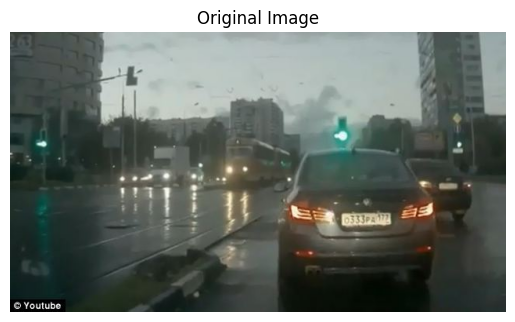

In [2]:
image = cv2.imread("/content/car_plate.jpg")
imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(imageRGB)
plt.title("Original Image")
plt.axis("off")
plt.show()

**TASK: Create a function that displays the image in a larger scale and correct coloring for matplotlib.**

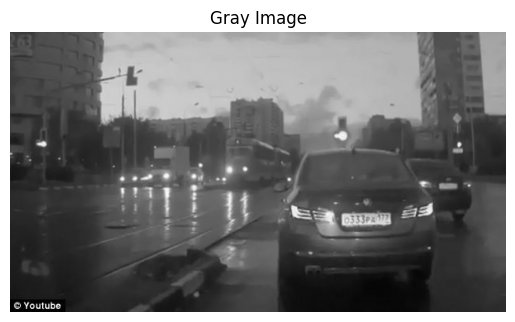

In [3]:
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(imageGray, cmap='gray')
plt.title("Gray Image")
plt.axis("off")
plt.show()

In [4]:
imageB, imageG, imageR = cv2.split(image)

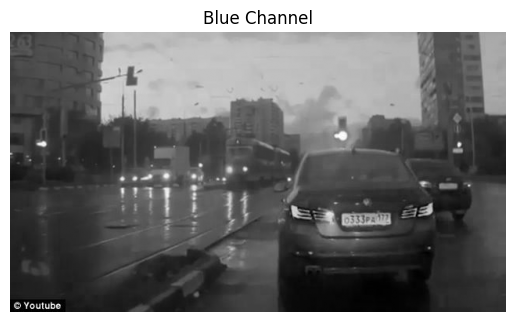

In [5]:
plt.imshow(imageB, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

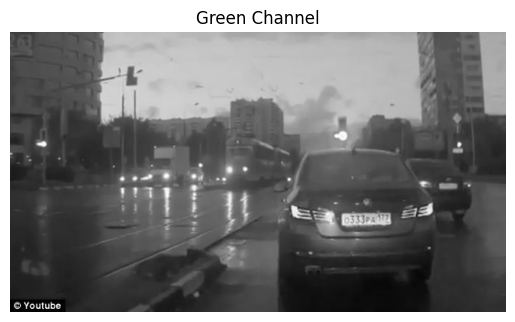

In [6]:
plt.imshow(imageG, cmap='gray')
plt.title("Green Channel")
plt.axis("off")
plt.show()

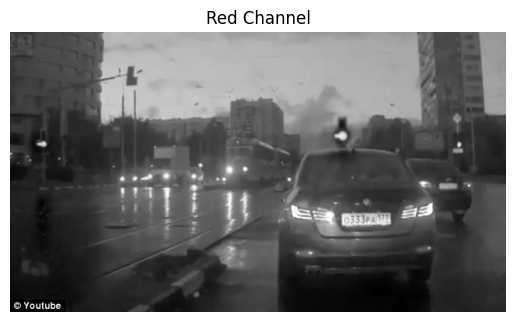

In [7]:
plt.imshow(imageR, cmap='gray')
plt.title("Red Channel")
plt.axis("off")
plt.show()

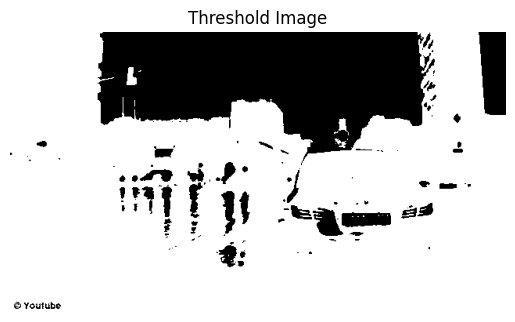

In [8]:
ret, imageThresh = cv2.threshold(
    imageGray,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.imshow(imageThresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

In [9]:
kernel = np.ones((5,5), np.uint8)

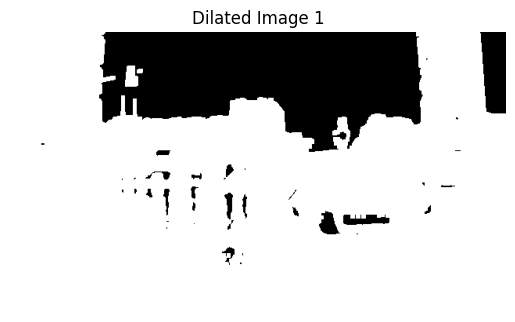

In [10]:
imageDilated1 = cv2.dilate(
    imageThresh,
    kernel,
    iterations=1
)

plt.imshow(imageDilated1, cmap='gray')
plt.title("Dilated Image 1")
plt.axis("off")
plt.show()

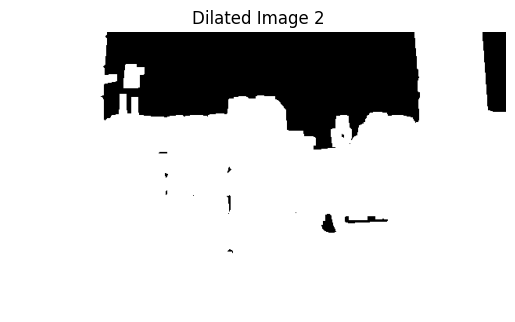

In [11]:
imageDilated2 = cv2.dilate(
    imageDilated1,
    kernel,
    iterations=1
)

plt.imshow(imageDilated2, cmap='gray')
plt.title("Dilated Image 2")
plt.axis("off")
plt.show()

In [12]:
kernelErode = np.ones((3,3), np.uint8)

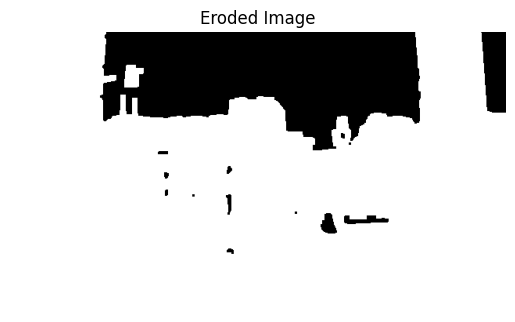

In [13]:
imageEroded = cv2.erode(
    imageDilated2,
    kernelErode,
    iterations=1
)

plt.imshow(imageEroded, cmap='gray')
plt.title("Eroded Image")
plt.axis("off")
plt.show()

In [17]:
params = cv2.SimpleBlobDetector_Params()

# Set blob detection parameters
params.minThreshold = 10
params.maxThreshold = 200
params.filterByArea = True
params.minArea = 1500
params.maxArea = 100000
params.filterByCircularity = True
params.minCircularity = 0.8
params.filterByConvexity = True
params.minConvexity = 0.9
params.filterByInertia = True
params.minInertiaRatio = 0.01

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(imageEroded)

print("Coins Detected:", len(keypoints))

Coins Detected: 0


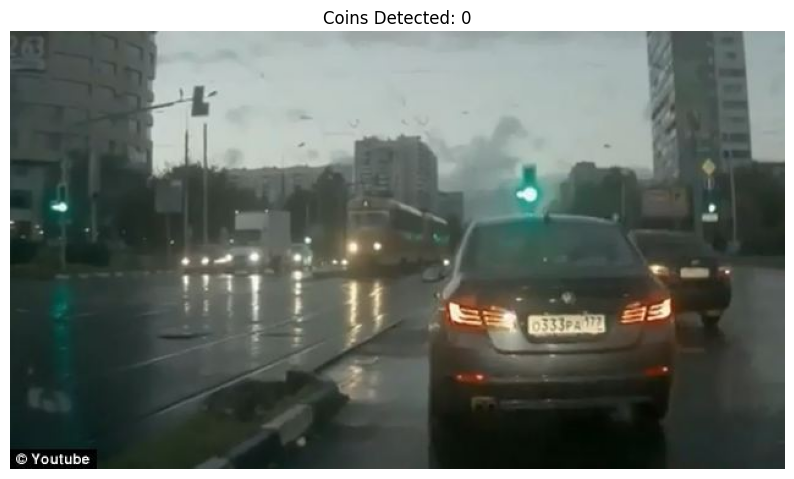

In [18]:
detectedCoins = cv2.drawKeypoints(
    imageRGB,
    keypoints,
    np.array([]),
    (255, 0, 0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10,10))
plt.imshow(detectedCoins)
plt.title(f"Coins Detected: {len(keypoints)}")
plt.axis("off")
plt.show()